### Surprisal Analysis
March 31, 2026

Models: GPT-2 / Gemma
Unidirectional vs. Bidirectional (Bayesian) Surprisal.

Bidirectional Implementation:
$$
P(w_t|w_{1:t-1}, w_{t+1:n})=\frac{P(w_{t:n} |w_{1:t-1})}{\sum_{w \in \mathcal{V}}P(w, w_{t+1:n} |w_{1:t-1})}
$$

In [ ]:
import torch
import torch.nn.functional as F

def check_k_coverage(metadata, k_values=[500, 1000, 5000, 10000]):
    coverage = {k: [] for k in k_values}
    
    for entry in metadata:
        logits = torch.tensor(entry['token_data'][0]['logits'], dtype=torch.float32)
        log_probs = F.log_softmax(logits, dim=-1)
        probs = log_probs.exp()
        
        sorted_probs, _ = torch.sort(probs, descending=True)
        cumulative = torch.cumsum(sorted_probs, dim=0)
        
        for k in k_values:
            coverage[k].append(cumulative[k-1].item())
    
    print(f"{'K':<8} {'Mean Coverage':<18} {'Min Coverage':<18} {'% items < 0.99'}")
    print("-" * 60)
    for k in k_values:
        cov = torch.tensor(coverage[k])
        below = (cov < 0.99).float().mean().item()
        print(f"{k:<8} {cov.mean().item():<18.4f} {cov.min().item():<18.4f} {below:.1%}")

meta_dict = {k: torch.load(f"data_output/bk21_with_{s}_metadata.pt", weights_only=False) 
             for k, s in models.items() if os.path.exists(f"data_output/bk21_with_{s}_metadata.pt")}

for name, meta in meta_dict.items():
    print(f"\n=== {name} ===")
    check_k_coverage(meta)


=== GPT-2 ===
K        Mean Coverage      Min Coverage       % items < 0.99
------------------------------------------------------------
500      0.7991             0.4235             98.8%
1000     0.8649             0.5365             97.5%
5000     0.9684             0.8185             77.9%
10000    0.9893             0.9209             39.8%

=== Gemma-270m ===
K        Mean Coverage      Min Coverage       % items < 0.99
------------------------------------------------------------
500      0.9309             0.7164             88.9%
1000     0.9610             0.8039             80.2%
5000     0.9940             0.9477             19.3%
10000    0.9981             0.9788             0.8%

=== Gemma-12b ===
K        Mean Coverage      Min Coverage       % items < 0.99
------------------------------------------------------------
500      0.9763             0.8428             70.2%
1000     0.9883             0.9158             43.4%
5000     0.9983             0.9876             0

In [11]:
import torch
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy.stats import pearsonr, spearmanr

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100

models = {
    "GPT-2": "gpt2", 
    "Gemma-270m": "gemma270m", 
    "Gemma-12b": "gemma12b"
}

dfs = {}
for name, suffix in models.items():
    path = f"data_output/bk21_with_{suffix}.csv"
    if os.path.exists(path):
        dfs[name] = pd.read_csv(path)
        dfs[name]['condition'] = pd.Categorical(dfs[name]['condition'], categories=['HC', 'MC', 'LC'], ordered=True)

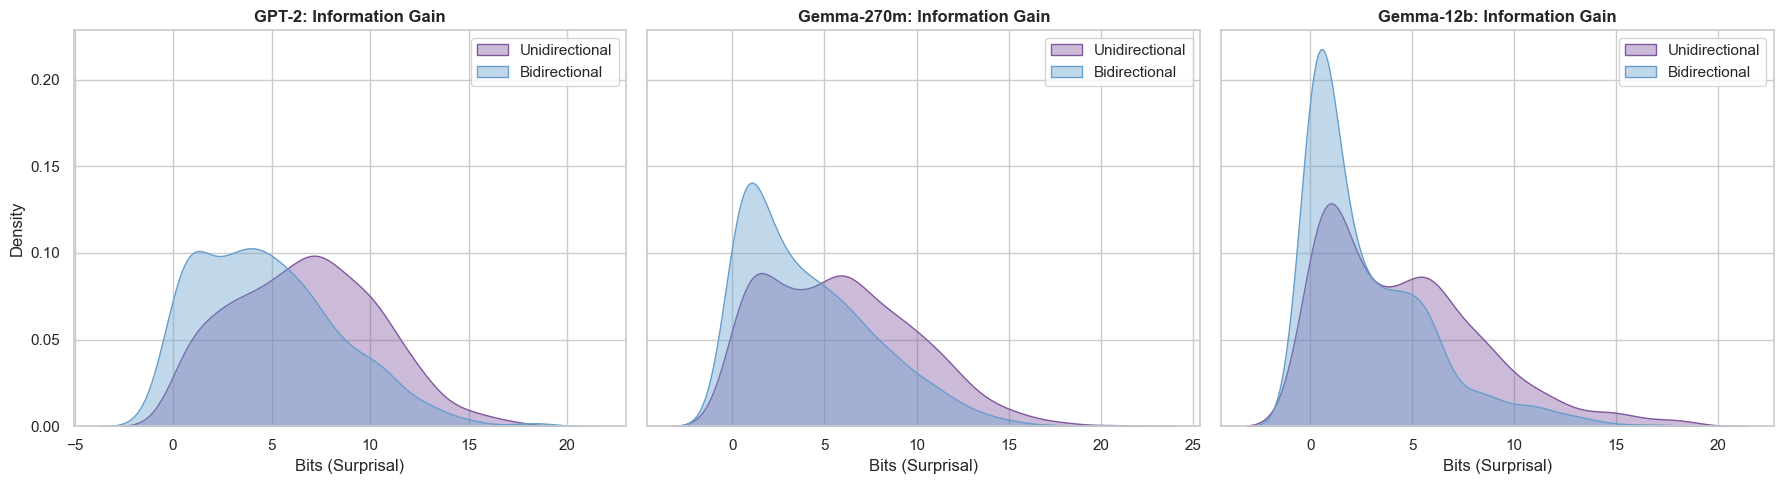

In [2]:
# 2. Global Distribution: Uni vs Bi (The "Cloze Gap")
if not dfs:
    print("No data found to plot.")
else:
    n_models = len(dfs)
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5), sharey=True, squeeze=False)
    
    for i, (name, df) in enumerate(dfs.items()):
        u_col = f"uni_surprisal"
        b_col = f"bi_surprisal"
        
        ax = axes[0, i] 
        
        sns.kdeplot(df[u_col], ax=ax, label='Unidirectional', fill=True, color="#80569E", alpha=0.4)
        
        sns.kdeplot(df[b_col], ax=ax, label='Bidirectional', fill=True, color="#669ECC", alpha=0.4)
        
        ax.set_title(f"{name}: Information Gain", fontweight='bold')
        ax.set_xlabel("Bits (Surprisal)")
        if i == 0: ax.set_ylabel("Density")
        ax.legend()

    plt.tight_layout()
    plt.show()

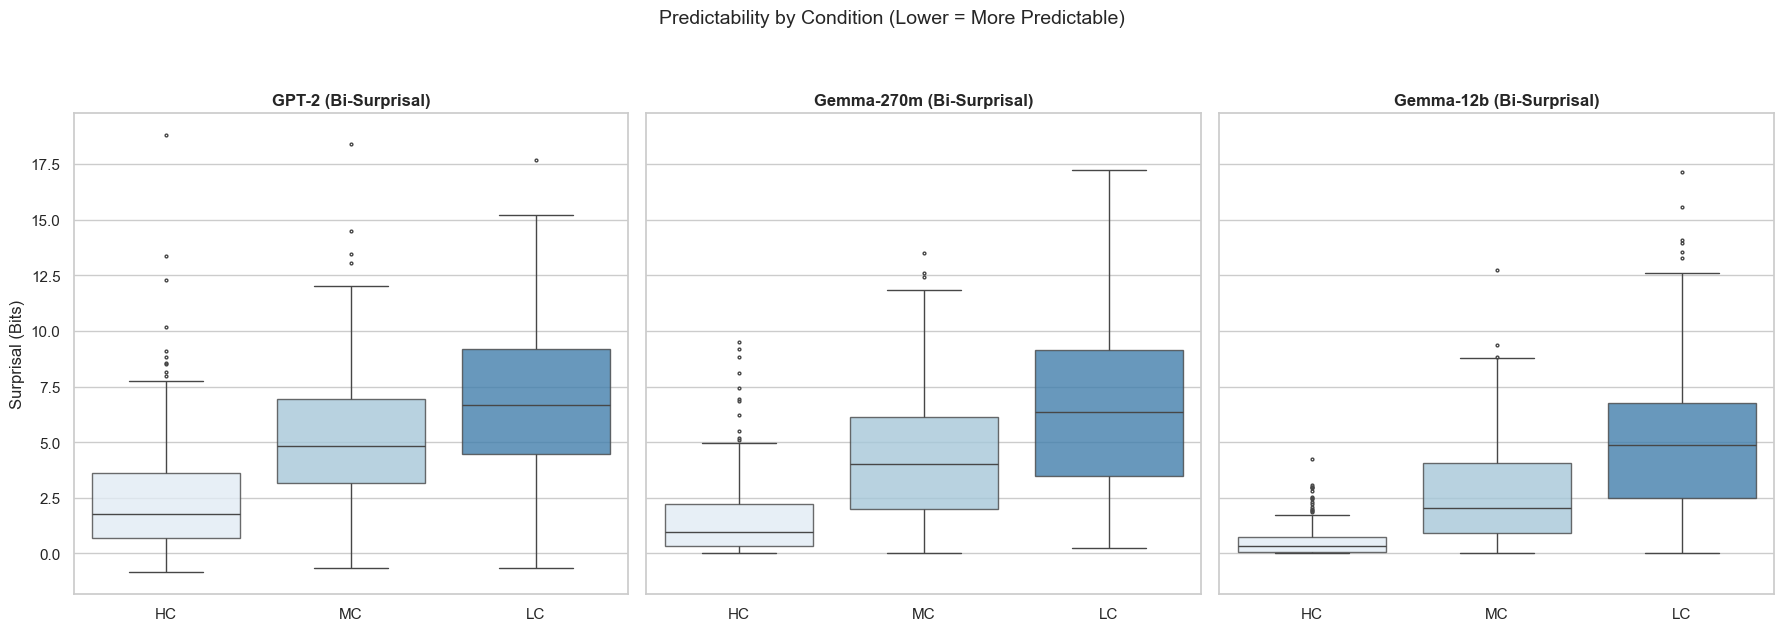

In [3]:
# 3. Model Performance across Conditions (HC, MC, LC)
if not dfs:
    print("No data found to plot.")
else:
    n_models = len(dfs)
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 6), sharey=True, squeeze=False)
    pal = {'HC': '#deebf7', 'MC': '#9ecae1', 'LC': '#3182bd'} 

    for i, (name, df) in enumerate(dfs.items()):
        b_col = f"bi_surprisal"
        
        ax = axes[0, i]
        
        sns.boxplot(
            data=df, x='condition', y=b_col, 
            palette=pal, ax=ax, hue='condition', legend=False,
            boxprops=dict(alpha=0.8), fliersize=2
        )
        
        ax.set_title(f"{name} (Bi-Surprisal)", fontweight='bold')
        ax.set_ylabel("Surprisal (Bits)" if i == 0 else "")
        ax.set_xlabel("")

    plt.suptitle("Predictability by Condition (Lower = More Predictable)", y=1.05, fontsize=14)
    plt.tight_layout()
    plt.show()

In [12]:
print("Correlation with Human Cloze Surprisal (S=200)")
corr_data = []

for name, df in dfs.items():
    u_col = f"uni_surprisal"
    b_col = f"bi_surprisal"
    cloze_col = 'cloze_surprisal' 
    valid = df.dropna(subset=[u_col, b_col, cloze_col])
    
    # Pearson (Linear correlation)
    r_uni_pearson, p_uni_p = pearsonr(valid[cloze_col], valid[u_col])
    r_bi_pearson, p_bi_p = pearsonr(valid[cloze_col], valid[b_col])
    
    # Spearman (Rank correlation)
    r_uni_spearman, p_uni_s = spearmanr(valid[cloze_col], valid[u_col])
    r_bi_spearman, p_bi_s = spearmanr(valid[cloze_col], valid[b_col])
    
    corr_data.append({
        "Model": name, 
        "Uni-Pearson": r_uni_pearson, 
        "Bi-Pearson": r_bi_pearson,
        "Uni-Spearman": r_uni_spearman,
        "Bi-Spearman": r_bi_spearman
    })

corr_df = pd.DataFrame(corr_data).set_index("Model")
display(corr_df.style.background_gradient(cmap='Blues'))

Correlation with Human Cloze Surprisal (S=200)


,Uni-Pearson,Bi-Pearson,Uni-Spearman,Bi-Spearman
Model,,,,
GPT-2,0.619587,0.474964,0.643605,0.513683
Gemma-270m,0.742774,0.582005,0.772269,0.619032
Gemma-12b,0.834451,0.640422,0.880184,0.693768


In [8]:
# 5. Metadata Inspection with Logit Tracking
meta_dict = {k: torch.load(f"data_output/bk21_with_{s}_metadata.pt", weights_only=False) 
             for k, s in models.items() if os.path.exists(f"data_output/bk21_with_{s}_metadata.pt")}

def inspect_item_detailed(idx):
    rows = []
    for name, metadata in meta_dict.items():
        entry = next((item for item in metadata if item['index'] == idx), None)
        if entry:
            token_info = entry['token_data'][0]
            rows.append({
                "Model": name,
                "Target_Tokens": "|".join([t['token_str'] for t in entry['token_data']]),
                "Uni": round(entry['uni_surprisal'], 3),
                "Bi": round(entry['bi_surprisal'], 3),
                "Benefit (U-B)": round(entry['uni_surprisal'] - entry['bi_surprisal'], 3),
                "Logit_Size": token_info['logits'].shape[0] if 'logits' in token_info else "N/A"
            })
    return pd.DataFrame(rows)

print(f"\nExample Item 0 Analysis:")
display(inspect_item_detailed(0))


Example Item 0 Analysis:


,Model,Target_Tokens,Uni,Bi,Benefit (U-B),Logit_Size
0,GPT-2,air,0.621,0.174,0.447,50257
1,Gemma-270m,air,0.998,0.480,0.519,262144
2,Gemma-12b,air,0.383,0.085,0.298,262208


In [10]:
print(df['suffix'].value_counts().head(20))

for name, df in dfs.items():
    u_col = f"uni_surprisal"
    b_col = f"bi_surprisal"
    pct = (df[b_col] > df[u_col]).mean()
    print(f"{name}: bi > uni in {pct:.1%} of items")

# for name, df in dfs.items():
#     b_col = f"bi_surprisal"
#     pct = (df[b_col] < 0).mean()
#     print(f"{name}: negative bi in {pct:.1%} of items")

suffix
at home.                   15
for some reason.            9
after all.                  9
in the bedroom.             6
made of silk.               6
in the corner.              6
last night.                 6
at breakfast.               6
all of a sudden.            6
and swung.                  3
that evening.               3
at the Farmer's market.     3
and peaceful.               3
earlier this afternoon.     3
and called 911.             3
on the floor.               3
and sleet.                  3
outside the building.       3
like we suggested.          3
that looked delicious.      3
Name: count, dtype: int64
GPT-2: bi > uni in 20.2% of items
Gemma-270m: bi > uni in 21.1% of items
Gemma-12b: bi > uni in 16.8% of items
